# Lab 1: From Data to Insight - SOLUTION
## MPS311/439 - Machine Learning
**Week 1 Lab Session**

**Exploratory Data Analysis with Python**

This solution contains working code and indicative interpretations. Student answers may differ when they are supported by the visual evidence.

## Setup


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_FILE = "bike_rentals.csv"

if not Path(DATA_FILE).exists():
    try:
        from google.colab import files
        print("Choose bike_rentals.csv from your computer.")
        files.upload()
    except ImportError:
        raise FileNotFoundError(
            "bike_rentals.csv was not found. Place it in the same folder as this notebook."
        )

df = pd.read_csv(DATA_FILE)
print("Dataset loaded successfully.")
print(type(df))


Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>


## Part 1: Meet the dataset


In [2]:
df.head()


,date,day,hour,temperature_c,humidity_pct,wind_speed_kmh,weather,is_weekend,rentals
0,2025-09-15,Monday,0,10.2,76.0,4.6,Clear,0,24
1,2025-09-15,Monday,1,8.3,75.0,6.2,Clear,0,4
2,2025-09-15,Monday,2,11.0,71.0,4.6,Clear,0,25
3,2025-09-15,Monday,3,11.8,70.0,5.6,Clear,0,25
4,2025-09-15,Monday,4,11.8,77.0,7.0,Clear,0,10


In [3]:
print("Rows and columns:", df.shape)
print("Column names:", df.columns.tolist())
df.info()


Rows and columns: (337, 9)
Column names: ['date', 'day', 'hour', 'temperature_c', 'humidity_pct', 'wind_speed_kmh', 'weather', 'is_weekend', 'rentals']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 337 entries, 0 to 336
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            337 non-null    object 
 1   day             337 non-null    object 
 2   hour            337 non-null    int64  
 3   temperature_c   336 non-null    float64
 4   humidity_pct    336 non-null    float64
 5   wind_speed_kmh  336 non-null    float64
 6   weather         337 non-null    object 
 7   is_weekend      337 non-null    int64  
 8   rentals         337 non-null    int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 23.8+ KB


One row represents the weather conditions and number of bicycle rentals for one hour. The target is `rentals`. Possible features include `temperature_c`, `humidity_pct`, `hour`, `weather`, and `is_weekend`.


In [4]:
df.describe()


,hour,temperature_c,humidity_pct,wind_speed_kmh,is_weekend,rentals
count,337.000000,336.000000,336.000000,336.000000,337.000000,337.000000
mean,11.465875,14.010417,71.571429,8.111905,0.287834,60.525223
std,6.950475,4.537826,7.751800,2.066082,0.453427,47.577194
min,0.000000,4.000000,56.000000,4.500000,0.000000,4.000000
25%,5.000000,10.075000,66.000000,6.475000,0.000000,10.000000
50%,11.000000,13.900000,71.000000,8.150000,0.000000,58.000000
75%,17.000000,18.025000,76.000000,9.800000,1.000000,97.000000
max,23.000000,23.300000,94.000000,12.700000,1.000000,162.000000


## Part 2: Check data quality


In [5]:
missing_values = df.isna().sum()
print(missing_values)
print("Total missing cells:", missing_values.sum())


date              0
day               0
hour              0
temperature_c     1
humidity_pct      1
wind_speed_kmh    1
weather           0
is_weekend        0
rentals           0
dtype: int64
Total missing cells: 3


In [6]:
duplicate_rows = df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)


Duplicate rows: 1


In [7]:
df_clean = (
    df.drop_duplicates()
      .dropna()
      .copy()
)

print("Original shape:", df.shape)
print("Clean shape:   ", df_clean.shape)
print("Rows removed:  ", len(df) - len(df_clean))


Original shape: (337, 9)
Clean shape:    (333, 9)
Rows removed:   4


The broken code uses `rental`, but the actual column name is `rentals`.


In [8]:
average_rentals = df_clean["rentals"].mean()
print("Average rentals:", average_rentals)


Average rentals: 60.609609609609606


Verification should include checking `df_clean.columns`, confirming the code runs, and checking that the resulting mean is within the observed range.

## Part 3: Explore individual variables


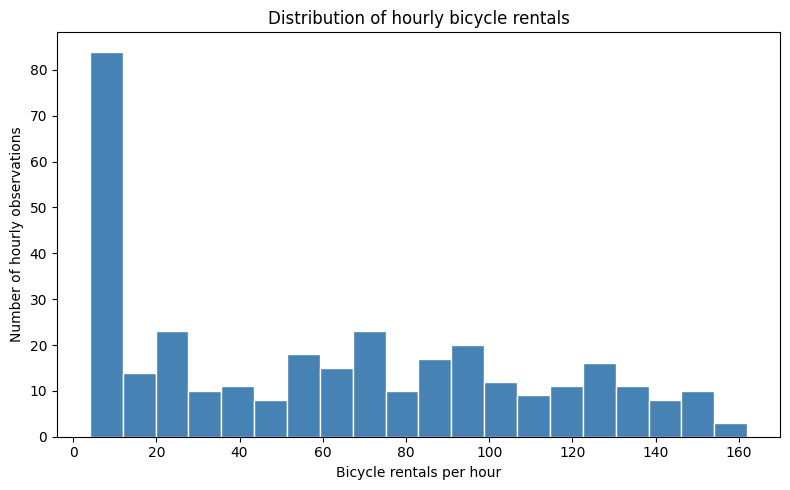

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["rentals"], bins=20, color="steelblue", edgecolor="white")
plt.xlabel("Bicycle rentals per hour")
plt.ylabel("Number of hourly observations")
plt.title("Distribution of hourly bicycle rentals")
plt.tight_layout()
plt.show()


The distribution contains many low-to-medium rental hours and a smaller number of high-demand periods. The mean therefore does not describe every hour equally well.


Clear     180
Cloudy    113
Rain       40
Name: weather, dtype: int64


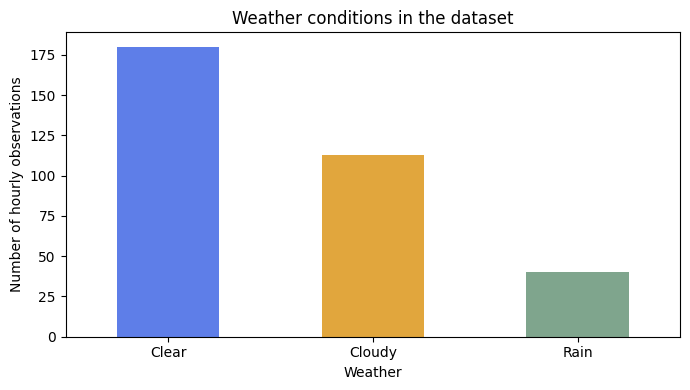

In [10]:
weather_counts = df_clean["weather"].value_counts()
print(weather_counts)

plt.figure(figsize=(7, 4))
weather_counts.plot(kind="bar", color=["#5e7ee8", "#e1a63d", "#7fa58d"])
plt.xlabel("Weather")
plt.ylabel("Number of hourly observations")
plt.title("Weather conditions in the dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Part 4: Explore relationships


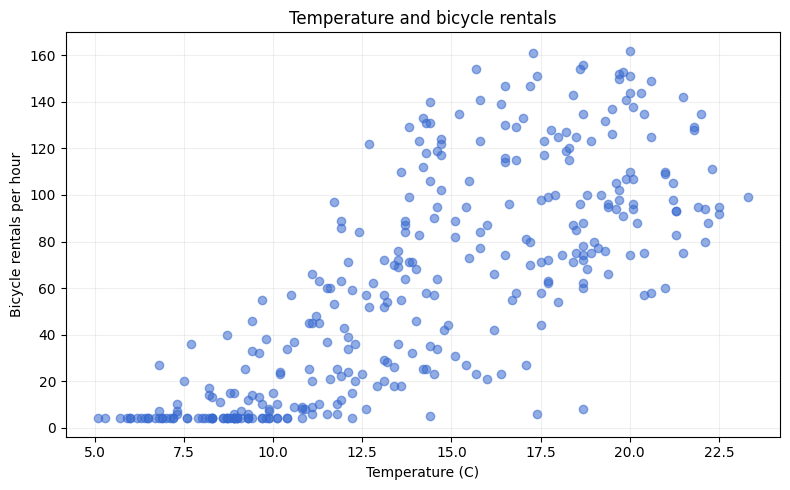

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["temperature_c"],
    df_clean["rentals"],
    alpha=0.55,
    color="#3769cf"
)
plt.xlabel("Temperature (C)")
plt.ylabel("Bicycle rentals per hour")
plt.title("Temperature and bicycle rentals")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


The overall relationship is positive, but there is substantial variation at similar temperatures. Hour, weather, and weekday/weekend patterns are possible confounders. The plot shows association, not proof of causation.


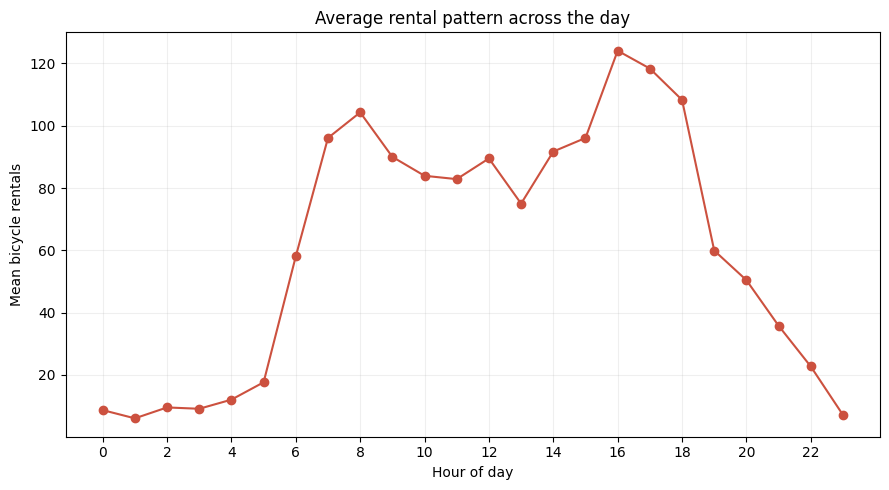

In [12]:
hourly_rentals = df_clean.groupby("hour")["rentals"].mean()

plt.figure(figsize=(9, 5))
plt.plot(hourly_rentals.index, hourly_rentals.values, marker="o", color="#cc513f")
plt.xlabel("Hour of day")
plt.ylabel("Mean bicycle rentals")
plt.title("Average rental pattern across the day")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


The strongest weekday peaks occur around morning and evening commuting times. Weekend demand is more concentrated around the middle of the day.

## Part 5: Compare groups and investigate


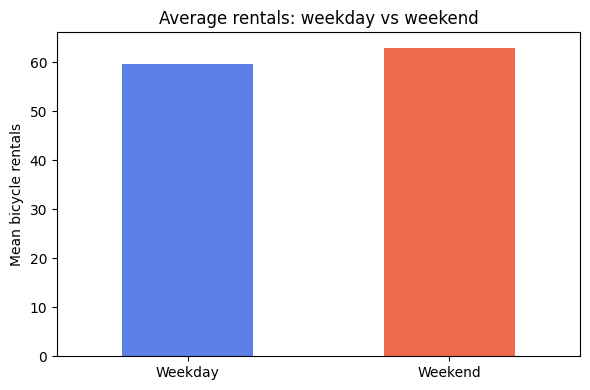

In [13]:
weekend_comparison = df_clean.groupby("is_weekend")["rentals"].mean()
weekend_comparison.index = ["Weekday", "Weekend"]

plt.figure(figsize=(6, 4))
weekend_comparison.plot(kind="bar", color=["#5e7ee8", "#ef6a4d"])
plt.xlabel("")
plt.ylabel("Mean bicycle rentals")
plt.title("Average rentals: weekday vs weekend")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


An overall mean hides the different shapes of hourly demand. A useful follow-up is to compare the complete weekday and weekend hourly profiles.

### Example mini-investigation: Weather conditions


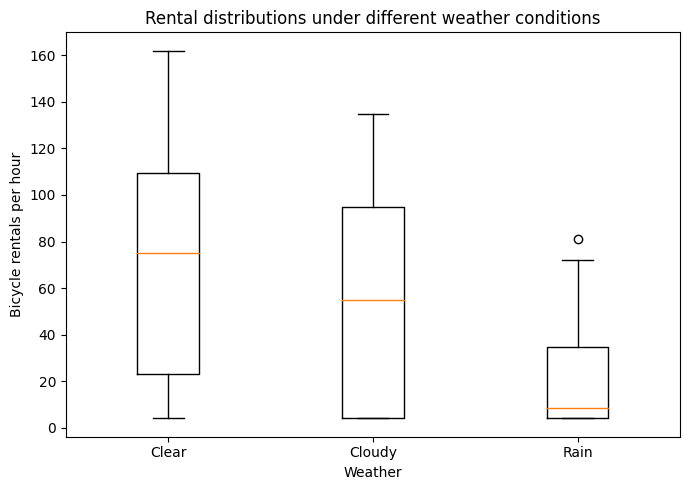

In [14]:
weather_order = ["Clear", "Cloudy", "Rain"]
weather_data = [
    df_clean.loc[df_clean["weather"] == condition, "rentals"]
    for condition in weather_order
]

plt.figure(figsize=(7, 5))
plt.boxplot(weather_data)
plt.xticks(range(1, len(weather_order) + 1), weather_order)
plt.xlabel("Weather")
plt.ylabel("Bicycle rentals per hour")
plt.title("Rental distributions under different weather conditions")
plt.tight_layout()
plt.show()


Indicative finding: rainy hours generally have lower rentals than clear hours. This does not prove that rain alone caused the difference because temperature, hour, and day type also vary.

## Reflection: indicative answers

1. A feature is an input used to describe or predict an observation; the target is the outcome we want to predict.
2. Missing values may break methods, reduce usable observations, or bias conclusions if the missingness is systematic.
3. Possible confounders include hour, weather condition, and weekday/weekend status.
4. Run the fix, inspect the output, compare it with the documented columns and plausible ranges, and explain why the change addresses the error.

# MPS439 Extension solution

## Reusable data audit


In [15]:
def audit_dataframe(data):
    """Return a compact quality report for a pandas DataFrame."""
    print(f"Shape: {data.shape[0]} rows x {data.shape[1]} columns")
    print("\nData types:")
    print(data.dtypes)
    print("\nMissing values:")
    print(data.isna().sum())
    print(f"\nDuplicate rows: {data.duplicated().sum()}")
    print("\nNumerical summary:")
    return data.describe()


audit_dataframe(df)


Shape: 337 rows x 9 columns

Data types:
date               object
day                object
hour                int64
temperature_c     float64
humidity_pct      float64
wind_speed_kmh    float64
weather            object
is_weekend          int64
rentals             int64
dtype: object

Missing values:
date              0
day               0
hour              0
temperature_c     1
humidity_pct      1
wind_speed_kmh    1
weather           0
is_weekend        0
rentals           0
dtype: int64

Duplicate rows: 1

Numerical summary:


,hour,temperature_c,humidity_pct,wind_speed_kmh,is_weekend,rentals
count,337.000000,336.000000,336.000000,336.000000,337.000000,337.000000
mean,11.465875,14.010417,71.571429,8.111905,0.287834,60.525223
std,6.950475,4.537826,7.751800,2.066082,0.453427,47.577194
min,0.000000,4.000000,56.000000,4.500000,0.000000,4.000000
25%,5.000000,10.075000,66.000000,6.475000,0.000000,10.000000
50%,11.000000,13.900000,71.000000,8.150000,0.000000,58.000000
75%,17.000000,18.025000,76.000000,9.800000,1.000000,97.000000
max,23.000000,23.300000,94.000000,12.700000,1.000000,162.000000


## Multivariable exploration


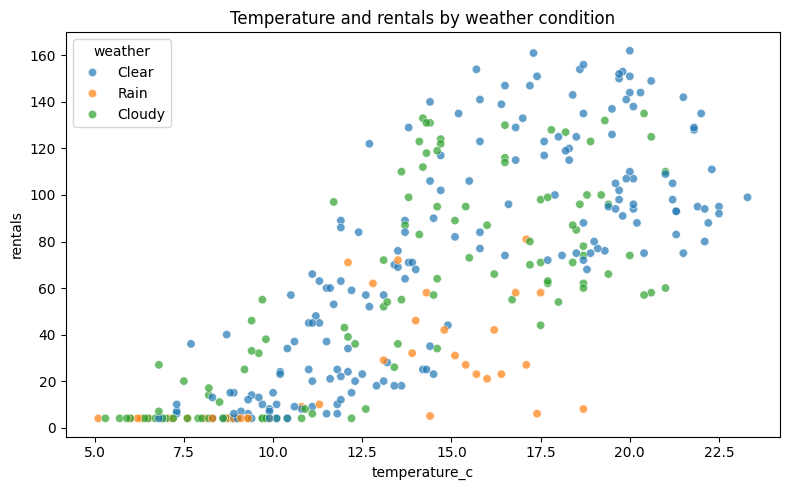

In [16]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_clean,
    x="temperature_c",
    y="rentals",
    hue="weather",
    alpha=0.7
)
plt.title("Temperature and rentals by weather condition")
plt.tight_layout()
plt.show()


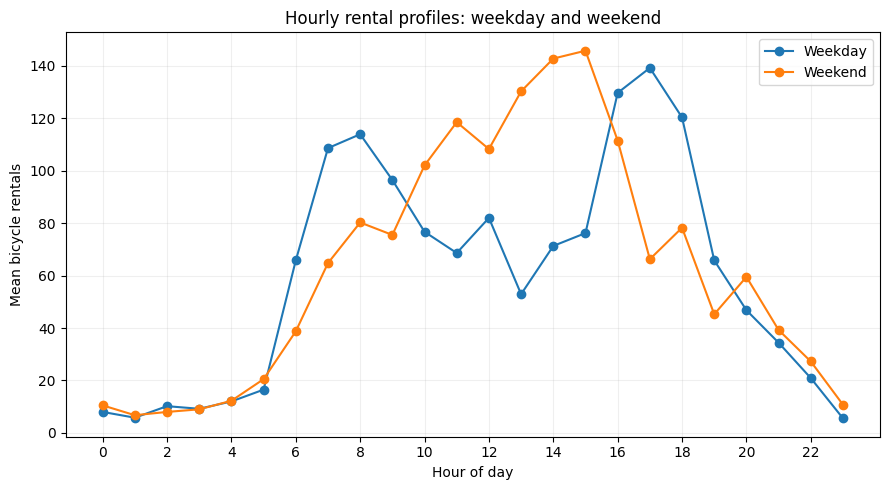

In [17]:
hourly_by_weekend = (
    df_clean.groupby(["hour", "is_weekend"])["rentals"]
            .mean()
            .unstack()
            .rename(columns={0: "Weekday", 1: "Weekend"})
)

plt.figure(figsize=(9, 5))
plt.plot(hourly_by_weekend.index, hourly_by_weekend["Weekday"], marker="o", label="Weekday")
plt.plot(hourly_by_weekend.index, hourly_by_weekend["Weekend"], marker="o", label="Weekend")
plt.xlabel("Hour of day")
plt.ylabel("Mean bicycle rentals")
plt.title("Hourly rental profiles: weekday and weekend")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


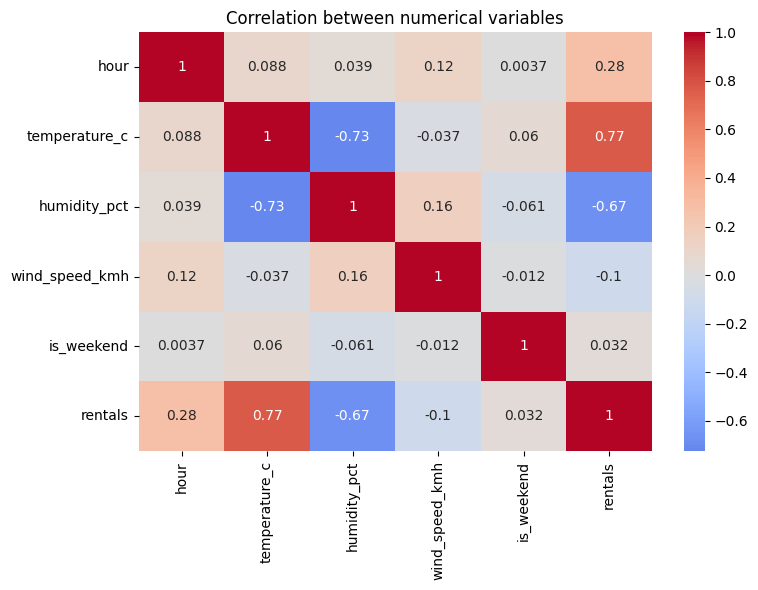

In [18]:
numeric_columns = [
    "hour", "temperature_c", "humidity_pct",
    "wind_speed_kmh", "is_weekend", "rentals"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df_clean[numeric_columns].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between numerical variables")
plt.tight_layout()
plt.show()


The heatmap is descriptive. `hour` is cyclical rather than an ordinary continuous scale, and `is_weekend` is binary. Their correlations should not be interpreted in the same way as measurements such as temperature.

## Example mini-report

**Question:** How does the hourly rental pattern differ between weekdays and weekends?

**Evidence:** Weekdays show two pronounced peaks around typical morning and evening commuting times. Weekend rentals rise later and form a broader midday peak.

**Interpretation:** The pattern is consistent with weekday commuting and weekend leisure travel. However, the dataset is synthetic and covers only 14 days, so it cannot establish behaviour in a real city.

**Limitation:** Weather conditions are not distributed identically across every day and hour. Some apparent weekday/weekend differences may therefore reflect weather as well as travel purpose.

**Next step:** A predictive model could include hour, weekend status, weather, and interactions between hour and weekend status. It should be evaluated on days not used for training.
